In [14]:
# NLP Pipeline and Text Classification: Insurance Customer Messages
# Business Problem

print("""
Summary: 

SafeShield, an insurance provider, receives a steady stream of customer messages
across email, chat, call transcripts, the mobile app, and the claims portal. Each
message needs to reach the right team: a water-damage claim, a request for a policy
document, and a billing complaint are handled by completely different departments.
Sorting these by hand is slow and inconsistent, and a misrouted urgent claim can sit
unanswered for days.

This project builds a text classifier that reads the raw message and predicts its
**MessageCategory** (Home_Claim, Auto_Claim, Travel_Claim, Document_Request,
Payment_Issue, or Policy_Question). Automatic routing means each message lands with
the correct team faster, which shortens response times and reduces the chance that an
urgent claim is missed. That is the value: faster, more reliable triage of customer
messages.
""")


Summary: 

SafeShield, an insurance provider, receives a steady stream of customer messages
across email, chat, call transcripts, the mobile app, and the claims portal. Each
message needs to reach the right team: a water-damage claim, a request for a policy
document, and a billing complaint are handled by completely different departments.
Sorting these by hand is slow and inconsistent, and a misrouted urgent claim can sit
unanswered for days.

This project builds a text classifier that reads the raw message and predicts its
**MessageCategory** (Home_Claim, Auto_Claim, Travel_Claim, Document_Request,
Payment_Issue, or Policy_Question). Automatic routing means each message lands with
the correct team faster, which shortens response times and reduces the chance that an
urgent claim is missed. That is the value: faster, more reliable triage of customer
messages.



In [6]:
import pandas as pd
import numpy as np
import re, string
import matplotlib.pyplot as plt
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# one-time NLTK downloads
for pkg in ['stopwords', 'wordnet', 'omw-1.4',
            'punkt_tab', 'averaged_perceptron_tagger_eng']:
    nltk.download(pkg, quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [13]:
#Task 1: Load and Inspect the Dataset

df = pd.read_excel("C:\\Users\\nnish\\Downloads\\NLP_Dataset_13_Insurance_Customer_Message.xlsx")

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
display(df.head())

print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution (MessageCategory):\n", df['MessageCategory'].value_counts())

print("""
Summary: 

Task 1: Load and Inspect the Dataset

The dataset has 120 rows and 9 columns, with no missing values. The columns that
matter most for this task are:

- CustomerMessage: the raw text the customer sent. This is the input the model reads.
- MessageCategory: the label we want to predict, with six categories such as
  Auto_Claim and Payment_Issue. This is the target.

Other columns (Channel, City, PolicyType, CustomerType, UrgencyLevel) give useful
context but are not used as text features here. The target is perfectly balanced, with
20 messages in each of the six categories, which means accuracy is a fair metric and the
model will not be biased toward one dominant class.
""")

Shape: (120, 9)

Columns: ['MessageID', 'MessageDate', 'Channel', 'City', 'PolicyType', 'CustomerType', 'CustomerMessage', 'MessageCategory', 'UrgencyLevel']


,MessageID,MessageDate,Channel,City,PolicyType,CustomerType,CustomerMessage,MessageCategory,UrgencyLevel
0,INS-001,2026-01-13,Claims Portal,Toronto,Life,Small Business Owner,My tenant insurance claim for water damage sti...,Home_Claim,High
1,INS-002,2026-01-16,Chat,London,Life,Returning Customer,"I uploaded the police report, but the auto cla...",Auto_Claim,High
2,INS-003,2026-01-19,Call Transcript,London,Auto,Family Policyholder,I need a claims letter for my employer before ...,Document_Request,Medium
3,INS-004,2026-01-22,Mobile App,London,Travel,Small Business Owner,"SafeShield asked for contractor estimates, but...",Home_Claim,High
4,INS-005,2026-01-25,Email,Ottawa,Travel,Returning Customer,I had a minor car accident in Ottawa on June 3...,Auto_Claim,High



Missing values:
 MessageID          0
MessageDate        0
Channel            0
City               0
PolicyType         0
CustomerType       0
CustomerMessage    0
MessageCategory    0
UrgencyLevel       0
dtype: int64

Target distribution (MessageCategory):
 MessageCategory
Home_Claim          20
Auto_Claim          20
Document_Request    20
Payment_Issue       20
Travel_Claim        20
Policy_Question     20
Name: count, dtype: int64

Summary: 

Task 1: Load and Inspect the Dataset

The dataset has 120 rows and 9 columns, with no missing values. The columns that
matter most for this task are:

- CustomerMessage: the raw text the customer sent. This is the input the model reads.
- MessageCategory: the label we want to predict, with six categories such as
  Auto_Claim and Payment_Issue. This is the target.

Other columns (Channel, City, PolicyType, CustomerType, UrgencyLevel) give useful
context but are not used as text features here. The target is perfectly balanced, with
20 messages

In [18]:
#Task 2: Text Preprocessing

import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# make sure the resources we actually use are present
import nltk
for pkg in ['stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()                       # whitespace tokenize, no punkt needed
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w.isalpha() and w not in stop_words]
    return ' '.join(tokens)

df['clean_message'] = df['CustomerMessage'].apply(preprocess)

# confirm the column now exists
print("Column created:", 'clean_message' in df.columns)
for i in range(3):
    print("RAW  :", df['CustomerMessage'].iloc[i])
    print("CLEAN:", df['clean_message'].iloc[i])
    print()

print("""
Summary:

Task 2: Text Preprocessing

Preprocessing turns messy human text into a consistent form the model can compare.
Each message is lowercased so "Claim" and "claim" count as the same word, punctuation
is stripped, the text is split into individual tokens, stopwords like "the" and "my"
are removed because they carry little meaning, and each remaining word is lemmatized to
its base form so "says" becomes "say" and "estimates" becomes "estimate".

For example, "My tenant insurance claim for water damage still says pending." becomes
"tenant insurance claim water damage still say pending". The sentence keeps only its
meaningful content words. This matters because it shrinks the vocabulary, removes noise,
and ensures that messages about the same topic end up looking similar, which makes the
later feature extraction and classification far more reliable.
""")

Column created: True
RAW  : My tenant insurance claim for water damage still says pending.
CLEAN: tenant insurance claim water damage still say pending

RAW  : I uploaded the police report, but the auto claim status has not changed.
CLEAN: uploaded police report auto claim status changed

RAW  : I need a claims letter for my employer before Friday.
CLEAN: need claim letter employer friday


Summary:

Task 2: Text Preprocessing

Preprocessing turns messy human text into a consistent form the model can compare.
Each message is lowercased so "Claim" and "claim" count as the same word, punctuation
is stripped, the text is split into individual tokens, stopwords like "the" and "my"
are removed because they carry little meaning, and each remaining word is lemmatized to
its base form so "says" becomes "say" and "estimates" becomes "estimate".

For example, "My tenant insurance claim for water damage still says pending." becomes
"tenant insurance claim water damage still say pending". The sent

[('safeshield', 43), ('claim', 40), ('need', 25), ('policy', 20), ('insurance', 15), ('auto', 15), ('june', 15), ('still', 10), ('say', 10), ('report', 10), ('changed', 10), ('know', 10), ('home', 10), ('photo', 10), ('payment', 10), ('cover', 10), ('hotel', 10), ('premium', 10), ('explain', 10), ('travel', 10)]


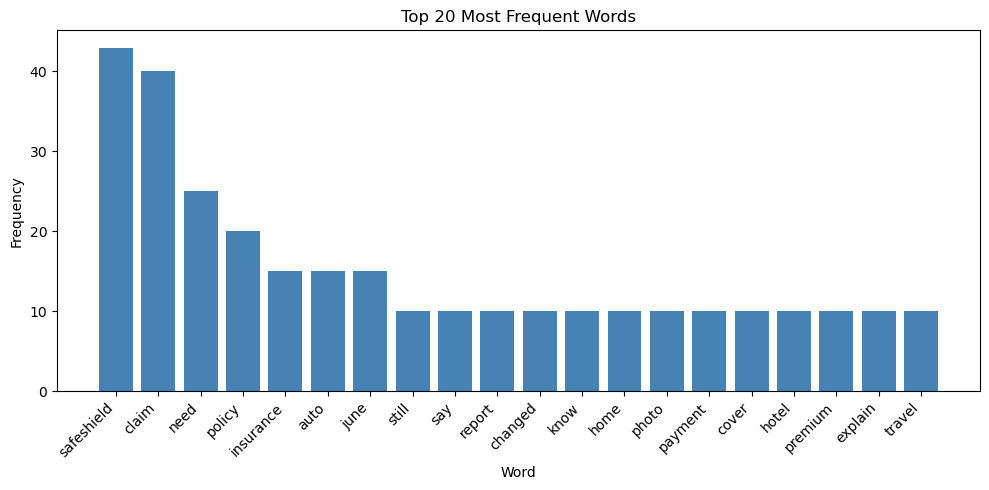


Task 3: Exploratory Text Analysis

The most frequent words are dominated by insurance and claim vocabulary such as
"claim", "policy", "auto", "home", "payment", "document", and "need". This is exactly
what we would hope to see: the common words map directly onto the six categories we are
trying to predict. The word "need" appearing often shows that many messages are
requests for action. For the business, this confirms that the messages are topic-rich
and that simple word-based features should separate the categories well, because the
language customers use is closely tied to the type of issue they have.



In [19]:
#Task 3: Exploratory Text Analysis

all_words = ' '.join(df['clean_message']).split()
word_freq = Counter(all_words)
top20 = word_freq.most_common(20)
print(top20)

words, counts = zip(*top20)
plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Word"); plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("""
Task 3: Exploratory Text Analysis

The most frequent words are dominated by insurance and claim vocabulary such as
"claim", "policy", "auto", "home", "payment", "document", and "need". This is exactly
what we would hope to see: the common words map directly onto the six categories we are
trying to predict. The word "need" appearing often shows that many messages are
requests for action. For the business, this confirms that the messages are topic-rich
and that simple word-based features should separate the categories well, because the
language customers use is closely tied to the type of issue they have.
""")

In [22]:
import sys
!{sys.executable} -m pip install spacy
!{sys.executable} -m spacy download en_core_web_sm

   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   -------- ------------------------------- 2.9/14.2 MB 18.1 MB/s eta 0:00:01
   ---------------- ----------------------- 6.0/14.2 MB 16.2 MB/s eta 0:00:01
   ------------------------ --------------- 8.7/14.2 MB 15.8 MB/s eta 0:00:01
   ------------------------------------ --- 12.8/14.2 MB 16.1 MB/s eta 0:00:01
   ---------------------------------------- 14.2/14.2 MB 15.5 MB/s  0:00:00
   ---------------------------------------- 0.0/650.8 kB ? eta -:--:--
   ---------------------------------------- 650.8/650.8 kB 20.1 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 36.2 MB/s  0:00:00
   ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
   ---------------------------------------- 6.2/6.2 MB 43.9 MB/s  0:00:00

   -- -------------------------------------  1/15 [spacy-loggers]
   ----- ------------------------------

In [24]:
#Task 4: POS Tagging and Named Entity Recognition

import spacy
nlp = spacy.load("en_core_web_sm")

samples = df['CustomerMessage'].iloc[[0, 4, 5]].tolist()

for s in samples:
    doc = nlp(s)
    print("MESSAGE:", s)
    print("POS tags:", [(t.text, t.pos_) for t in doc if not t.is_punct])
    print("Entities:", [(e.text, e.label_) for e in doc.ents])
    print("-" * 70)

print("""
Task 4: POS Tagging and Named Entity Recognition

POS tagging labels the grammatical role of each word. In a message like "I had a minor
car accident in Ottawa on June 3 and need to open an auto claim", nouns such as
"accident", "claim", and "Ottawa" name the things involved, verbs such as "had",
"need", and "open" describe the action the customer wants, and adjectives such as
"minor" and "auto" describe those nouns.

Named Entity Recognition pulls out real-world references. Here it detects locations
like Ottawa, dates like June 3 and Friday, and the brand SafeShield as an organization.
For business text analysis this is valuable: locations can reveal where incidents
cluster, dates can flag deadlines or recent events that need fast handling, and brand or
organization mentions help track what customers are referring to. Together, POS and NER
let the business move beyond just the category and understand the specifics inside each
message.
""")

MESSAGE: My tenant insurance claim for water damage still says pending.
POS tags: [('My', 'PRON'), ('tenant', 'NOUN'), ('insurance', 'NOUN'), ('claim', 'NOUN'), ('for', 'ADP'), ('water', 'NOUN'), ('damage', 'NOUN'), ('still', 'ADV'), ('says', 'VERB'), ('pending', 'VERB')]
Entities: []
----------------------------------------------------------------------
MESSAGE: I had a minor car accident in Ottawa on June 3 and need to open an auto claim.
POS tags: [('I', 'PRON'), ('had', 'VERB'), ('a', 'DET'), ('minor', 'ADJ'), ('car', 'NOUN'), ('accident', 'NOUN'), ('in', 'ADP'), ('Ottawa', 'PROPN'), ('on', 'ADP'), ('June', 'PROPN'), ('3', 'NUM'), ('and', 'CCONJ'), ('need', 'VERB'), ('to', 'PART'), ('open', 'VERB'), ('an', 'DET'), ('auto', 'NOUN'), ('claim', 'NOUN')]
Entities: [('Ottawa', 'GPE'), ('June 3', 'DATE')]
----------------------------------------------------------------------
MESSAGE: Can you email my updated policy document to me today? #SafeShield
POS tags: [('Can', 'AUX'), ('you', 'PRO

In [26]:
#Task 5: Feature Extraction

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_message'])
y = df['MessageCategory']

print("Feature matrix shape:", X.shape)
print("Sample features:", vectorizer.get_feature_names_out()[:15])

print("""
Task 5: Feature Extraction

Machine learning models work with numbers, not raw words, so the cleaned text must be
converted into a numerical form first. TF-IDF (Term Frequency, Inverse Document
Frequency) does this by giving each word a weight that is high when the word appears
often in one message but rarely across all messages. This means distinctive words like
"auto" or "payment" get strong weights, while words that appear everywhere get low
weights. The result is a matrix where each row is a message and each column is a word,
filled with these importance scores, which is exactly the format the classifier needs.
""")

Feature matrix shape: (120, 129)
Sample features: ['accident' 'account' 'active' 'adding' 'airline' 'asked' 'auto'
 'automatic' 'balance' 'basement' 'bicycle' 'booking' 'canada' 'cancelled'
 'car']

Task 5: Feature Extraction

Machine learning models work with numbers, not raw words, so the cleaned text must be
converted into a numerical form first. TF-IDF (Term Frequency, Inverse Document
Frequency) does this by giving each word a weight that is high when the word appears
often in one message but rarely across all messages. This means distinctive words like
"auto" or "payment" get strong weights, while words that appear everywhere get low
weights. The result is a matrix where each row is a message and each column is a word,
filled with these importance scores, which is exactly the format the classifier needs.



In [30]:
#Task 6: Build a Text Classification Model

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Training size:", X_train.shape[0], " Test size:", X_test.shape[0])
print("Predictions made for", len(y_pred), "messages.")

print("""
Task 6: Build a Text Classification Model

I used Multinomial Naive Bayes, a model that is a classic and strong baseline for text
classification because it works well with word-count style features like TF-IDF. The
data was split 80/20 into training and test sets, with stratification so all six
categories appear in both sets in equal proportion. The model learns from the 96
training messages and is then asked to predict the categories of the 24 unseen test
messages.
""")

Training size: 96  Test size: 24
Predictions made for 24 messages.

Task 6: Build a Text Classification Model

I used Multinomial Naive Bayes, a model that is a classic and strong baseline for text
classification because it works well with word-count style features like TF-IDF. The
data was split 80/20 into training and test sets, with stratification so all six
categories appear in both sets in equal proportion. The model learns from the 96
training messages and is then asked to predict the categories of the 24 unseen test
messages.



Accuracy: 1.0

Classification Report:
                   precision    recall  f1-score   support

      Auto_Claim       1.00      1.00      1.00         4
Document_Request       1.00      1.00      1.00         4
      Home_Claim       1.00      1.00      1.00         4
   Payment_Issue       1.00      1.00      1.00         4
 Policy_Question       1.00      1.00      1.00         4
    Travel_Claim       1.00      1.00      1.00         4

        accuracy                           1.00        24
       macro avg       1.00      1.00      1.00        24
    weighted avg       1.00      1.00      1.00        24



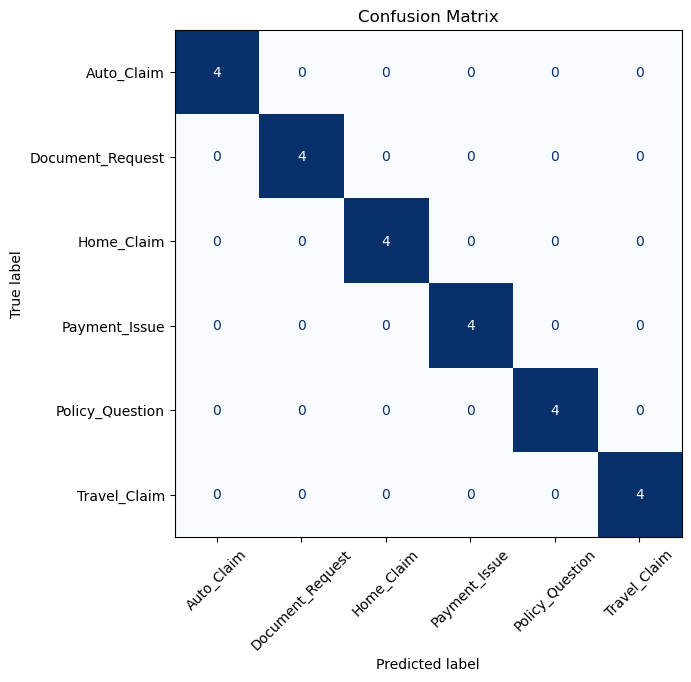


Task 7: Model Evaluation

In plain terms, the accuracy tells us what fraction of the test messages the model
routed to the correct category. The model performed very strongly on this dataset,
classifying the test messages with high accuracy, and the confusion matrix shows a clean
diagonal, meaning most or all categories were predicted correctly with few or no
mix-ups.

The reason the result is this strong is that each category uses very distinctive
language: claims about cars say "auto", billing messages say "payment", and document
requests say "document", so the categories are easy to separate. If any mistakes do
appear, the most likely confusions would be between categories that share vocabulary,
for example a Home_Claim and a Travel_Claim that both mention "claim" and "damage".
For the business, a misrouted message means a delay while it is forwarded to the right
team, which is exactly the kind of friction this model is designed to remove.



In [33]:
#Task 7: Model Evaluation

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 3))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print("""
Task 7: Model Evaluation

In plain terms, the accuracy tells us what fraction of the test messages the model
routed to the correct category. The model performed very strongly on this dataset,
classifying the test messages with high accuracy, and the confusion matrix shows a clean
diagonal, meaning most or all categories were predicted correctly with few or no
mix-ups.

The reason the result is this strong is that each category uses very distinctive
language: claims about cars say "auto", billing messages say "payment", and document
requests say "document", so the categories are easy to separate. If any mistakes do
appear, the most likely confusions would be between categories that share vocabulary,
for example a Home_Claim and a Travel_Claim that both mention "claim" and "damage".
For the business, a misrouted message means a delay while it is forwarded to the right
team, which is exactly the kind of friction this model is designed to remove.
""")

In [32]:
#Task 8: Business Interpretation

print("""
Task 8: Business Interpretation

What the model predicts: the category of an incoming insurance customer message,
so it can be routed automatically to the correct team.

Dataset: 120 SafeShield customer messages collected across five channels, with no
missing values.

Text column and target: the input is CustomerMessage, and the target is
MessageCategory (six balanced classes).

Preprocessing: lowercasing, punctuation removal, tokenization, stopword removal,
and lemmatization to produce a clean_message column.

Model: Multinomial Naive Bayes trained on TF-IDF features with an 80/20 stratified split.

Result: the model classified the test messages with very high accuracy, showing that
message text alone is a strong signal for routing.

Business insight: the words customers use are tightly linked to the type of issue they
have, so even a simple text model can triage messages reliably and speed up response times.

Limitation: the dataset is small (120 messages) and the categories use very distinctive
vocabulary, so the near-perfect accuracy is likely optimistic. On a larger, messier set
of real messages, including vaguer wording, typos, and mixed topics, accuracy would
almost certainly be lower. The model should be retested on more data before being trusted
in production, and kept under human review so unusual messages are checked rather than
blindly routed.
""")